In [1]:
import gymnasium as gym
import numpy as np
import cv2
import ale_py

from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecFrameStack
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.atari_wrappers import FireResetEnv

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
from datetime import datetime

In [3]:
gym.register_envs(ale_py)

In [4]:
log_dir = "./logs_breakout/"
os.makedirs(log_dir, exist_ok=True)

In [5]:
class WhitePatchBreakout(gym.Wrapper):
    def __init__(self, env, apply_patch=False, region=(20, 40, 30, 30)):
        super().__init__(env)
        self.apply_patch = apply_patch
        self.x, self.y, self.w, self.h = region

    def _paint_patch(self, img):
        if not self.apply_patch:
            return img
        
        # Copia para não alterar o buffer original inadvertidamente
        img = img.copy()
        
        # Detecta dimensões (pode ser 84x84 ou a resolução nativa no render)
        H, W = img.shape[:2]
        
        x, y, w, h = self.x, self.y, self.w, self.h
        
        # Garante que o desenho não exceda as bordas
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            # Pinta de branco (255). Funciona tanto para RGB quanto Grayscale se ajustado
            img[y:y_end, x:x_end] = 255
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._paint_patch(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._paint_patch(obs), reward, terminated, truncated, info

    def render(self):
        # Mágica para o vídeo: Pega o render original e aplica a mancha nele
        img = self.env.render()
        return self._paint_patch(img)

In [6]:
class BlurBreakout(gym.Wrapper):
    def __init__(self, env, apply_blur=False, region=(20, 40, 30, 30), ksize=21):
        super().__init__(env)
        self.apply_blur = apply_blur
        self.x, self.y, self.w, self.h = region
        self.ksize = ksize if ksize % 2 == 1 else ksize + 1

    def _apply_blur(self, img):
        if not self.apply_blur:
            return img
        
        img = img.copy()
        H, W = img.shape[:2]
        x, y, w, h = self.x, self.y, self.w, self.h
        
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            roi = img[y:y_end, x:x_end]
            # Aplica Gaussian Blur na região de interesse
            blurred_roi = cv2.GaussianBlur(roi, (self.ksize, self.ksize), 0)
            img[y:y_end, x:x_end] = blurred_roi
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._apply_blur(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._apply_blur(obs), reward, terminated, truncated, info
    
    def render(self):
        img = self.env.render()
        return self._apply_blur(img)

In [7]:
class GrayscaleWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Força explicitamente o shape (H, W, 1) para compatibilidade com SB3
        old_shape = self.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(old_shape[0], old_shape[1], 1), dtype=np.uint8
        )

    def _convert(self, obs):
        # Se for RGB (3 canais), converte para Gray e mantém dimensão extra
        if obs.ndim == 3 and obs.shape[2] == 3:
            return cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)[:, :, None]
        return obs

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._convert(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._convert(obs), reward, terminated, truncated, info

In [8]:
def _create_base_gym_env(render_mode, with_modification, modification_type, log_dir=None):
    """
    Função interna para garantir que a ordem dos wrappers seja idêntica
    tanto no treino quanto no vídeo.
    """
    env = gym.make("ALE/Breakout-v5", render_mode=render_mode)
    
    # 1. Garante inicio do jogo
    env = FireResetEnv(env)
    
    # 2. Resize para 84x84 (Colorido)
    # façam sentido na imagem pequena.
    env = gym.wrappers.ResizeObservation(env, (84, 84))
    
    # 3. Aplica a Modificação Visual (Blur ou White Patch)
    if modification_type == 'white_patch':
        env = WhitePatchBreakout(env, apply_patch=with_modification, region=(20, 40, 30, 30))
    elif modification_type == 'blur':
        env = BlurBreakout(env, apply_blur=with_modification, region=(20, 40, 30, 30), ksize=21)
    

    if log_dir:
        env = Monitor(env, log_dir)
        
    return env

In [9]:
def make_training_env(with_blur=False, change='white_patch', log_dir="./logs/"):
    """
    Cria o ambiente de treino.
    Agora gera um arquivo monitor com TIMESTAMP para não sobrescrever os anteriores.
    Ex: ./logs/monitor_20231027_153000.csv
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)
    
    # Gera o timestamp UMA VEZ para este ambiente
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    def _init():
        # 1. Base Environment
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        
        # 2. Fire Reset
        env = FireResetEnv(env)
        
        # 3. Resize PRIMEIRO (Para 84x84)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 4. Aplica a Modificação (Blur ou White Patch)
        if change == 'white_patch':
            # Usa sua classe com apply_patch=with_blur
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # 5. Grayscale (Transforma em H, W, 1)
        env = GrayscaleWrapper(env)
        
        # 6. Monitor (AGORA COM TIMESTAMP NO NOME)
        if log_dir:
            # Cria o caminho: ./logs/monitor_20231123_220000
            # O SB3 adiciona .csv automaticamente na maioria das versões
            filename = os.path.join(log_dir, f"monitor_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    # 7. Vetorização (SB3)
    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [10]:
def make_training_env(with_blur=False, change='white_patch', log_dir="./logs/"):
    """
    Cria o ambiente de treino mantendo a consistência exata com o ambiente de avaliação.
    Parâmetros renomeados para bater com sua chamada: with_blur, change.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    def _init():
        # 1. Base Environment
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        
        # 2. Fire Reset
        env = FireResetEnv(env)
        
        # 3. Resize PRIMEIRO (Para 84x84)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 4. Aplica a Modificação (Blur ou White Patch)
        if change == 'white_patch':
            # Usa sua classe com apply_patch=with_blur
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # 5. Grayscale (Transforma em H, W, 1)
        env = GrayscaleWrapper(env)
        
        # 6. Monitor
        if log_dir:
            env = Monitor(env, log_dir)
            
        return env

    # 7. Vetorização (SB3)
    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [11]:
def make_training_env(with_blur=False, change='white_patch', zone='middle', log_dir="./logs/"):
    """
    Cria ambiente com zonas configuráveis.
    Zonas disponíveis: 'top', 'middle', 'bottom'.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # Coordenadas fixas para 84x84 (Mantendo mancha de 30x30)
    # X=27 centraliza horizontalmente (84 - 30) / 2
    presets = {
        'top':    (27, 10, 30, 30), # Cobre os tijolos
        'middle': (27, 40, 30, 30), # Cobre a trajetória (Sua config original)
        'bottom': (27, 54, 30, 30)  # Cobre o Paddle (Agente)
    }
    
    # Seleciona a região baseada no nome, ou usa 'middle' como padrão
    region = presets.get(zone, (27, 40, 30, 30))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # Aplica a mancha na zona escolhida
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
        env = GrayscaleWrapper(env)
        
        if log_dir:
            # Adiciona o nome da zona no log para diferenciar depois
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = os.path.join(log_dir, f"monitor_{zone}_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [11]:
log_dir_clean = "./logs_clean/"   # Pasta para o treino NORMAL
log_dir_patch = "./logs_patch/"   # Pasta para o treino COM MANCHA

In [12]:
steps = 3_000_000

In [13]:
# DQN("CnnPolicy", 
#     env_blur, 
#     verbose=1,buffer_size=100_000,  
#     optimize_memory_usage=False,
#     learning_starts=50_000,
#     learning_rate=1e-4,
#     batch_size=32,
#     exploration_fraction=0.1,
#     exploration_final_eps=0.01,
#     train_freq=4,
#     target_update_interval=100,
#     gradient_steps=1,
#     tensorboard_log="./tensorboard_logs/")

In [14]:
# model_blur = DQN(
#     "CnnPolicy", 
#     env_blur, 
#     verbose=1, 
    
#     # 1. Memória (Buffer)
#     # Aumentar permite que o agente lembre de experiências mais antigas e variadas.
#     # Se der erro de memória RAM, diminua para 50_000 ou ative optimize_memory_usage=True
#     buffer_size=100_000,  
#     optimize_memory_usage=False, 

#     # 2. Quando começar a aprender
#     # Espere o buffer encher bastante antes de começar a atualizar os pesos.
#     # Isso evita overfitting em movimentos aleatórios iniciais.
#     learning_starts=50_000, 

#     # 3. Taxa de Aprendizado (Padrão Atari)
#     learning_rate=1e-4, 

#     # 4. Batch Size
#     # 32 é o clássico para Atari.
#     batch_size=32, 

#     # 5. Exploração (Epsilon-Greedy)
#     # exploration_fraction: Fração do total_timesteps que ele passa diminuindo a exploração.
#     # 0.1 (10%) de 1M steps = 100k steps explorando muito. 
#     exploration_fraction=0.1, 
#     # exploration_final_eps: No final, 1% de chance de movimento aleatório é melhor que 5% no Breakout.
#     exploration_final_eps=0.01, 

#     # 6. Frequência de Treino
#     # Treina a cada 4 passos do ambiente (Padrão do artigo Nature).
#     train_freq=4, 
    
#     # 7. Atualização da Rede Alvo (Estabilidade)
#     # A cada 1000 passos, copia os pesos para a rede alvo.
#     target_update_interval=1000, 
    
#     # 8. Gradiente
#     gradient_steps=1,
    
#     # (Opcional) Logs para Tensorboard (visualizar gráficos em tempo real)
#     tensorboard_log="./tensorboard_logs/"
# )

In [ ]:
print("--- Iniciando Treino SEM Blur ---")
env_normal = make_training_env(with_blur=False, change = 'white_patch', log_dir=log_dir_clean)
# model_normal = DQN("CnnPolicy", env_normal, verbose=1, buffer_size=50_000, learning_starts=10_000, train_freq=4) 
model_normal = DQN("CnnPolicy", 
    env_normal, 
    verbose=1,buffer_size=100_000,  
    optimize_memory_usage=False,
    learning_starts=50_000,
    learning_rate=1e-4,
    batch_size=32,
    exploration_fraction=0.1,
    exploration_final_eps=0.01,
    train_freq=4,
    target_update_interval=1000,
    gradient_steps=1)

model_normal.learn(total_timesteps=steps) # Baixo para teste rápido
model_normal.save("dqn_breakout_normal")
env_normal.close()

--- Iniciando Treino SEM Blur ---
Using cpu device
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 181      |
|    ep_rew_mean      | 1.25     |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1432     |
|    time_elapsed     | 0        |
|    total_timesteps  | 723      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 194      |
|    ep_rew_mean      | 1.62     |
|    exploration_rate | 0.995    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1466     |
|    time_elapsed     | 1        |
|    total_timesteps  | 1549     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 183      |
|    ep_rew_mean      | 1.33     |
|    exploration_rate | 0.993    |
| ti

In [20]:
print("\n--- Iniciando Treino COM Blur ---")
env_blur = make_training_env(with_blur=True, change = 'white_patch', log_dir=log_dir_patch)
# model_blur = DQN("CnnPolicy", env_blur, verbose=1, buffer_size=50_000, learning_starts=10_000, train_freq=4)
model_blur = DQN("CnnPolicy", 
    env_normal, 
    verbose=1,buffer_size=100_000,  
    optimize_memory_usage=False,
    learning_starts=50_000,
    learning_rate=1e-4,
    batch_size=32,
    exploration_fraction=0.1,
    exploration_final_eps=0.01,
    train_freq=4,
    target_update_interval=1000,
    gradient_steps=1)

model_blur.learn(total_timesteps=steps) # Baixo para teste rápido
model_blur.save("dqn_breakout_blur")
env_blur.close()


--- Iniciando Treino COM Blur ---
Using cpu device


c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\stable_baselines3\common\buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 5.65GB > 4.99GB
  warnings.warn(


ValueError: I/O operation on closed file.

In [34]:
# Configuração
steps_por_zona = 1_000_000  # Ajuste conforme seu tempo disponível
zonas = ['top', 'middle', 'bottom']

for zona in zonas:
    print(f"\n=============================================")
    print(f" INICIANDO TREINO: ZONA {zona.upper()}")
    print(f"=============================================")
    
    # Define diretório de log específico para não misturar
    log_dir = f"./logs_hipotese_{zona}/"
    
    # Cria ambiente na zona específica
    env = make_training_env(with_blur=True, change='white_patch', zone=zona, log_dir=log_dir)
    
    # Cria Modelo DQN (Configuração Otimizada que definimos antes)
    model = DQN(
        "CnnPolicy", 
        env, 
        verbose=1,buffer_size=100_000,
        optimize_memory_usage=False,
        learning_starts=50_000,
        learning_rate=1e-4,
        batch_size=32,
        exploration_fraction=0.1,
        exploration_final_eps=0.01,
        train_freq=4,
        target_update_interval=1000,
        gradient_steps=1
        )
    
    # Treina
    model.learn(total_timesteps=steps_por_zona)
    
    # Salva com nome distinto
    model.save(f"dqn_breakout_zone_{zona}")
    
    env.close()
    print(f"Modelo da zona {zona} salvo com sucesso!")

print("\n--- Todos os experimentos finalizados ---")


 INICIANDO TREINO: ZONA TOP
Using cpu device


c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\stable_baselines3\common\buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 5.65GB > 5.36GB
  warnings.warn(


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 194      |
|    ep_rew_mean      | 1.75     |
|    exploration_rate | 0.992    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1491     |
|    time_elapsed     | 0        |
|    total_timesteps  | 776      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 210      |
|    ep_rew_mean      | 2.12     |
|    exploration_rate | 0.983    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1483     |
|    time_elapsed     | 1        |
|    total_timesteps  | 1681     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 193      |
|    ep_rew_mean      | 1.67     |
|    exploration_rate | 0.977    |
| time/               |          |
|    episodes       

c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\stable_baselines3\common\buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 5.65GB > 4.39GB
  warnings.warn(


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 188      |
|    ep_rew_mean      | 1.5      |
|    exploration_rate | 0.993    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1301     |
|    time_elapsed     | 0        |
|    total_timesteps  | 750      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 172      |
|    ep_rew_mean      | 1.12     |
|    exploration_rate | 0.986    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1302     |
|    time_elapsed     | 1        |
|    total_timesteps  | 1373     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 172      |
|    ep_rew_mean      | 1.08     |
|    exploration_rate | 0.98     |
| time/               |          |
|    episodes       

MemoryError: Unable to allocate 2.63 GiB for an array with shape (100000, 1, 4, 84, 84) and data type uint8

In [35]:
def get_latest_log_file(folder):
    """
    Busca na pasta o arquivo monitor*.csv mais recente (baseado na data de modificação).
    """
    # Procura por monitor.csv, monitor_2023....csv, etc.
    search_path = os.path.join(folder, "monitor*.csv")
    files = glob.glob(search_path)
    
    if not files:
        print(f"Aviso: Nenhum arquivo 'monitor*.csv' encontrado em {folder}")
        return None
    
    # Ordena pelo tempo de modificação (o último é o mais recente)
    latest_file = max(files, key=os.path.getmtime)
    print(f"Lendo log mais recente em '{folder}': {os.path.basename(latest_file)}")
    return latest_file

In [24]:
def plot_comparison(log_dir_1, name_1, log_dir_2, name_2):
    plt.figure(figsize=(12, 6))
    
    # Função interna para ler dados usando o helper
    def read_data(folder):
        file_path = get_latest_log_file(folder)
        if file_path is None:
            return None, None

        df = pd.read_csv(file_path, skiprows=1)
        if df.empty: return None, None
        
        x = df['l'].cumsum() # Steps acumulados
        y = df['r']          # Recompensa
        # Suavização (Média móvel de 100 episódios)
        y_smooth = y.rolling(window=100).mean()
        return x, y_smooth

    # Plota o Primeiro
    x1, y1 = read_data(log_dir_1)
    if x1 is not None:
        plt.plot(x1, y1, label=name_1, color='blue', linewidth=2)

    # Plota o Segundo
    x2, y2 = read_data(log_dir_2)
    if x2 is not None:
        plt.plot(x2, y2, label=name_2, color='red', linewidth=2, linestyle='--')

    plt.xlabel('Timesteps (Passos)')
    plt.ylabel('Recompensa Média (Média Móvel 100 ep)')
    plt.title('Comparação de Performance: Normal vs Oclusão')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Lendo log mais recente em './logs_clean/': monitor.csv
Lendo log mais recente em './logs_patch/': monitor.csv


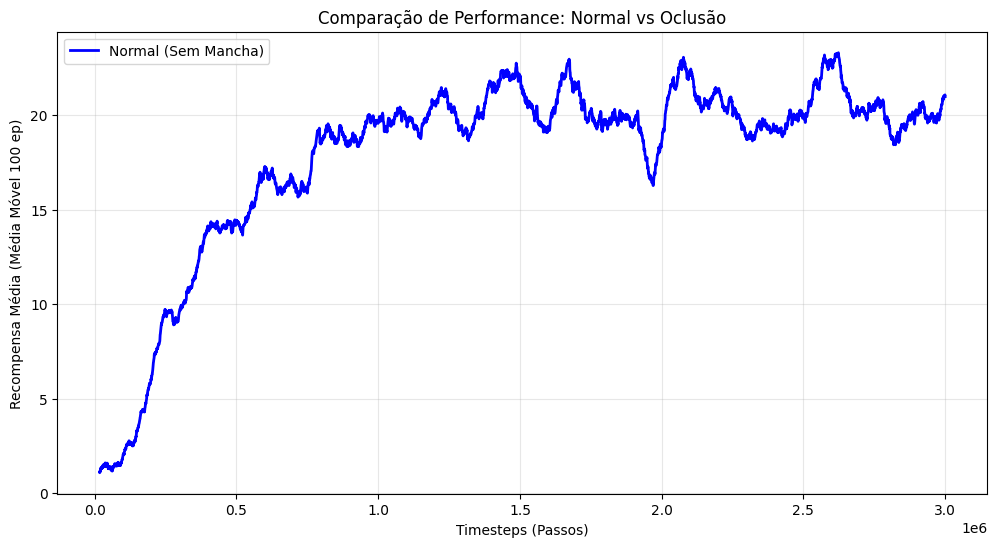

In [36]:
plot_comparison("./logs_clean/", "Normal (Sem Mancha)", "./logs_patch/", "Com Mancha Branca")

In [26]:
def plot_advanced_analysis(log_dir_1, name_1, log_dir_2, name_2):
    
    def read_dataframe(folder):
        file_path = get_latest_log_file(folder)
        if file_path is None:
            return None
        # Pula as duas primeiras linhas (header do SB3)
        try:
            df = pd.read_csv(file_path, skiprows=1)
            return df
        except Exception as e:
            print(f"Erro ao ler {file_path}: {e}")
            return None

    df1 = read_dataframe(log_dir_1)
    df2 = read_dataframe(log_dir_2)

    if df1 is None and df2 is None:
        print("Nenhum dado válido encontrado para plotar.")
        return

    # Cria uma figura com 3 subgráficos (gridspec para layout bonito)
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2)
    
    # --- GRÁFICO 1: RECOMPENSA (Média Móvel) ---
    ax1 = fig.add_subplot(gs[0, :]) # Ocupa a linha inteira superior
    window = 100
    
    if df1 is not None and not df1.empty:
        x1 = df1['l'].cumsum()
        y1 = df1['r'].rolling(window=window).mean()
        ax1.plot(x1, y1, label=f"{name_1}", color='blue')
        std1 = df1['r'].rolling(window=window).std()
        ax1.fill_between(x1, y1-std1, y1+std1, color='blue', alpha=0.1)

    if df2 is not None and not df2.empty:
        x2 = df2['l'].cumsum()
        y2 = df2['r'].rolling(window=window).mean()
        ax1.plot(x2, y2, label=f"{name_2}", color='red', linestyle='--')
        std2 = df2['r'].rolling(window=window).std()
        ax1.fill_between(x2, y2-std2, y2+std2, color='red', alpha=0.1)

    ax1.set_title("1. Curva de Aprendizado (Recompensa Média)")
    ax1.set_ylabel("Pontos no Breakout")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- GRÁFICO 2: DURAÇÃO DO EPISÓDIO (Sobrevivência) ---
    ax2 = fig.add_subplot(gs[1, 0])
    
    if df1 is not None and not df1.empty:
        y1_len = df1['l'].rolling(window=window).mean()
        ax2.plot(x1, y1_len, color='blue')

    if df2 is not None and not df2.empty:
        y2_len = df2['l'].rolling(window=window).mean()
        ax2.plot(x2, y2_len, color='red', linestyle='--')
        
    ax2.set_title("2. Sobrevivência (Duração do Jogo)")
    ax2.set_ylabel("Frames por Episódio")
    ax2.set_xlabel("Total Timesteps")
    ax2.grid(True, alpha=0.3)
    
    # --- GRÁFICO 3: VELOCIDADE DE TREINO (FPS Real) ---
    ax3 = fig.add_subplot(gs[1, 1])
    
    if df1 is not None and not df1.empty:
        fps1 = x1.iloc[-1] / df1['t'].iloc[-1]
        ax3.bar(name_1, fps1, color='blue', alpha=0.6)
        ax3.text(name_1, fps1, f"{int(fps1)} FPS", ha='center', va='bottom')

    if df2 is not None and not df2.empty:
        fps2 = x2.iloc[-1] / df2['t'].iloc[-1]
        ax3.bar(name_2, fps2, color='red', alpha=0.6)
        ax3.text(name_2, fps2, f"{int(fps2)} FPS", ha='center', va='bottom')

    ax3.set_title("3. Velocidade de Treinamento (FPS)")
    ax3.set_ylabel("Frames por Segundo")

    plt.tight_layout()
    plt.show()

Lendo log mais recente em './logs_clean/': monitor.csv
Lendo log mais recente em './logs_patch/': monitor.csv


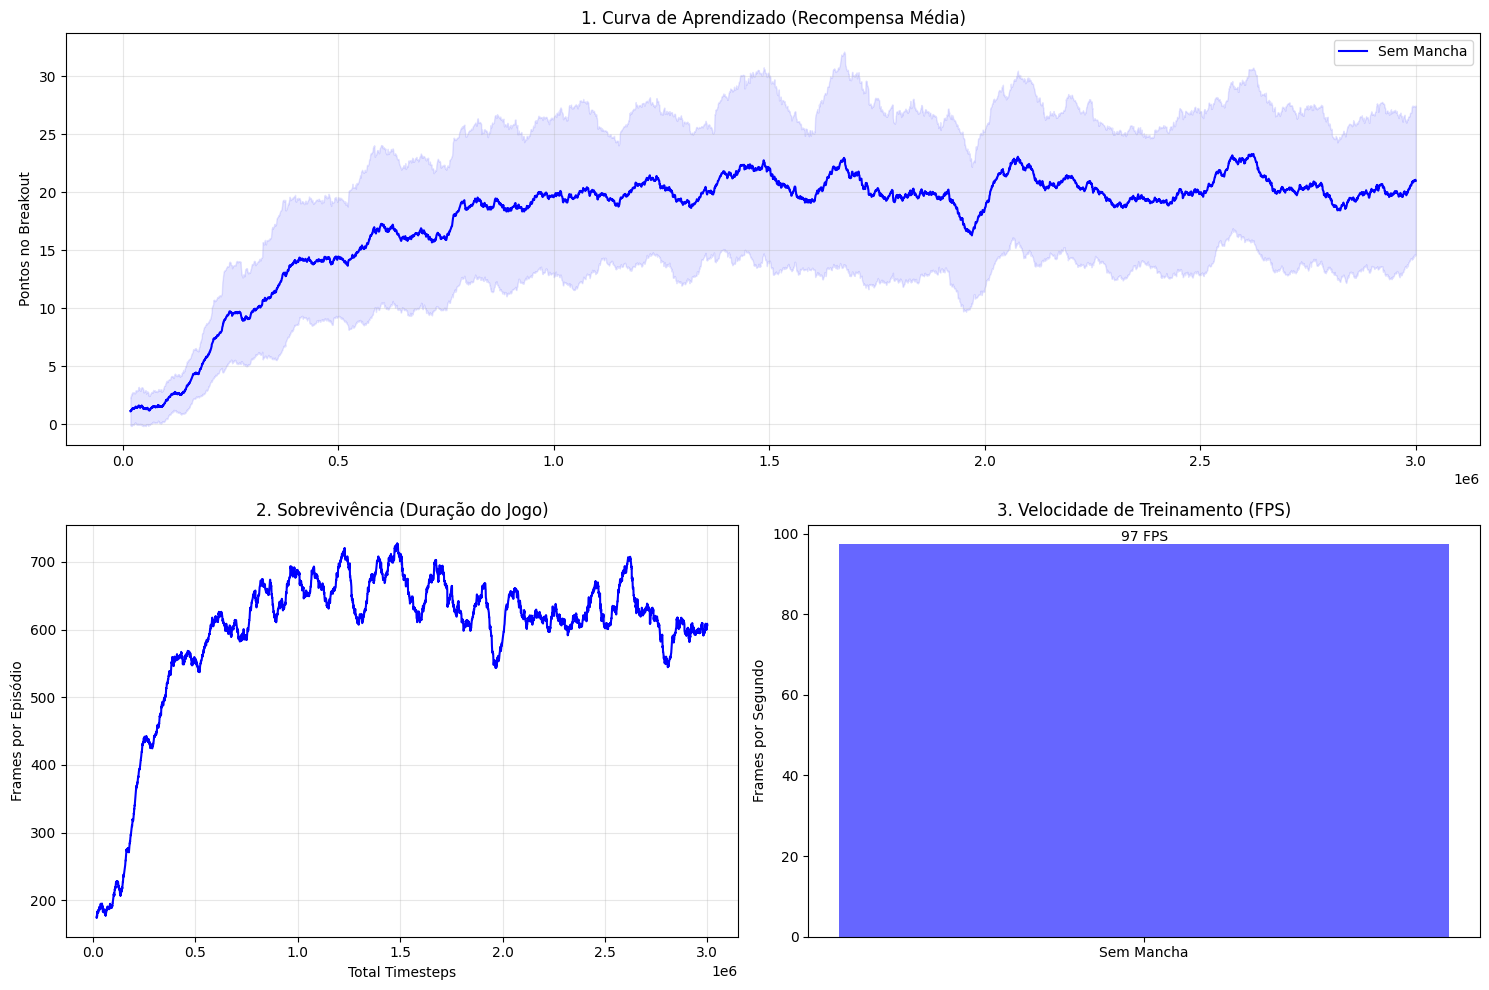

In [27]:
# Chama a função comparando as pastas que criamos antes
plot_advanced_analysis("./logs_clean/", "Sem Mancha", "./logs_patch/", "Com Mancha")

In [12]:
def record_video(model, name_prefix, with_blur, change='white_patch', zone='middle', n_episodes=1, max_steps=3000):
    video_folder = "./videos/"
    os.makedirs(video_folder, exist_ok=True)
    
    print(f"--- Gravando {name_prefix} [Zona: {zone}] (Max {max_steps} steps) ---")

    # Coordenadas das zonas (Devem ser IDÊNTICAS ao treino)
    presets = {
        'top':    (27, 10, 30, 30),
        'middle': (27, 40, 30, 30),
        'bottom': (27, 54, 30, 30)
    }
    region = presets.get(zone, (27, 40, 30, 30))

    def _create_video_env():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # Aplica a mancha na zona correta
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
        env = gym.wrappers.RecordVideo(
            env, 
            video_folder=video_folder, 
            name_prefix=name_prefix,
            episode_trigger=lambda x: True,
            disable_logger=True
        )
        
        env = GrayscaleWrapper(env)
        return env

    env = DummyVecEnv([_create_video_env])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)

    obs = env.reset()
    episodes_count = 0
    current_steps = 0
    last_lives = 5 
    
    try:
        while episodes_count < n_episodes:
            action, _ = model.predict(obs, deterministic=True)
            
            # --- Anti-Stuck: Força FIRE se ficar parado demais ---
            # (Mantenha sua lógica de vidas ou use um contador de ações repetidas)
            
            obs, rewards, done, infos = env.step(action)
            current_steps += 1
            
            # Checagem de vidas para atualizar last_lives
            for info in infos:
                lives = info.get("lives", 0)
                if lives < last_lives:
                    last_lives = lives
            
            if current_steps > max_steps:
                print(f"ALERTA: Episódio excedeu {max_steps} passos. Forçando parada.")
                done = [True]
            
            for i, d in enumerate(done):
                if d:
                    episodes_count += 1
                    current_steps = 0
                    last_lives = 5
                    score = infos[i].get('episode', {}).get('r', 0)
                    print(f"Episódio {episodes_count} finalizado | Score: {score}")
                    obs = env.reset()
                    
    except KeyboardInterrupt:
        print("Interrompido.")
    finally:
        env.close()
        print(f"Vídeos salvos em {video_folder}")

In [13]:
if os.path.exists("dqn_breakout_zone_top.zip"):
    print(">>> Carregando Modelo TOP...")
    model_top = DQN.load("dqn_breakout_zone_top")
    
    record_video(
        model=model_top, 
        name_prefix="video_teste_TOP", 
        with_blur=True, 
        change='white_patch', 
        zone='top',  # <--- IMPORTANTE: Mudar para 'top'
        n_episodes=2
    )

>>> Carregando Modelo TOP...
--- Gravando video_teste_TOP [Zona: top] (Max 3000 steps) ---


c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\user\Documents\mestrado\BlurRL\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episódio 1 finalizado | Score: 0
Episódio 2 finalizado | Score: 0
Vídeos salvos em ./videos/


In [14]:
if os.path.exists("dqn_breakout_zone_middle.zip"): # Ou o nome que você usou antes
    print("\n>>> Carregando Modelo MIDDLE...")
    model_middle = DQN.load("dqn_breakout_zone_middle")
    
    record_video(
        model=model_middle, 
        name_prefix="video_teste_MIDDLE", 
        with_blur=True, 
        change='white_patch', 
        zone='middle', 
        n_episodes=2
    )


>>> Carregando Modelo MIDDLE...
--- Gravando video_teste_MIDDLE [Zona: middle] (Max 3000 steps) ---
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 1 finalizado | Score: 0
Episódio 2 finalizado | Score: 0
Vídeos salvos em ./videos/


In [ ]:
record_video(model_blur, "teste_com_blur", with_blur=True, change = 'white_patch', n_episodes=5)

--- Gravando teste_com_blur (Max 3000 steps) ---
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 1 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 2 finalizado | Score: 0
Episódio 3 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 4 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 5 finalizado | Score: 0
Vídeos salvos em ./videos/


In [31]:
record_video(model_normal, "teste_sem_blur", with_blur=False, change = 'white_patch', n_episodes=5, max_steps=100_000)

--- Gravando teste_sem_blur (Max 100000 steps) ---


c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\user\Documents\mestrado\BlurRL\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episódio 1 finalizado | Score: 0
Episódio 2 finalizado | Score: 0
Episódio 3 finalizado | Score: 0
Episódio 4 finalizado | Score: 0
Episódio 5 finalizado | Score: 0
Vídeos salvos em ./videos/
